**Download the dataset**

In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("ajg117/indian-paintings-dataset")

print("Path to dataset files:", path)

100%|██████████| 355M/355M [00:02<00:00, 125MB/s]

Extracting files...


Path to dataset files: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3


**Class names before writing the training code.**

In [ ]:
import os

print("Dataset path:", path)

for root, dirs, files in os.walk(path):
    level = root.replace(path, "").count(os.sep)
    indent = " " * 4 * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

Dataset path: /root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3
3/
    gond painting/
    warli painting/
    pichwai painting/
    kerala mural/
    madhubani painting/
    kalighat painting/
    mandana art drawing/
    kangra painting/


Install/import libraries

In [ ]:
import os
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split

import torchvision
from torchvision import datasets, transforms, models

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score
)

import seaborn as sns

In [ ]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

Device: cuda
GPU: Tesla T4


In [ ]:
dataset_path = "/root/.cache/kagglehub/datasets/ajg117/indian-paintings-dataset/versions/3"

verify the classes

In [ ]:
classes = sorted([
    d for d in os.listdir(dataset_path)
    if os.path.isdir(os.path.join(dataset_path, d))
])

print("Classes:")
for i, cls in enumerate(classes):
    print(i, ":", cls)

print("\nNumber of classes:", len(classes))

Classes:
0 : gond painting
1 : kalighat painting
2 : kangra painting
3 : kerala mural
4 : madhubani painting
5 : mandana art drawing
6 : pichwai painting
7 : warli painting

Number of classes: 8


Check number of images

In [ ]:
from collections import Counter

image_extensions = (".jpg", ".jpeg", ".png", ".bmp", ".webp")

class_counts = {}

for cls in classes:
    class_path = os.path.join(dataset_path, cls)

    count = sum(
        1 for file in os.listdir(class_path)
        if file.lower().endswith(image_extensions)
    )

    class_counts[cls] = count

print("Number of images per class:\n")

for cls, count in class_counts.items():
    print(f"{cls}: {count}")

print("\nTotal images:", sum(class_counts.values()))

Number of images per class:

gond painting: 98
kalighat painting: 244
kangra painting: 87
kerala mural: 94
madhubani painting: 95
mandana art drawing: 140
pichwai painting: 96
warli painting: 97

Total images: 951


# **Create train/validation/test datasets**
# Image preprocessing

The neural network doesn't directly work with arbitrary JPG images.

Images have different:

sizes, dimensions, pixel values

So we preprocess them.

In [ ]:
from torchvision.transforms import InterpolationMode

train_transform = transforms.Compose([
    transforms.Resize((224, 224)),            #224 × 224 pixels
    transforms.RandomHorizontalFlip(),        #This randomly flips an image horizontally.
    transforms.RandomRotation(15),            #The image can randomly rotate by up to approximately ±15 degrees.
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),
    transforms.ToTensor(),    # A normal image is represented by pixel values.
    transforms.Normalize(     # These are the standard ImageNet normalization values.
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Load dataset
ImageFolder can directly load your dataset because your images are arranged into class folders.

In [ ]:
full_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=train_transform
)

print("Total images:", len(full_dataset))
print("Classes:", full_dataset.classes)
print("Class to index:", full_dataset.class_to_idx)

Total images: 953
Classes: ['gond painting', 'kalighat painting', 'kangra painting', 'kerala mural', 'madhubani painting', 'mandana art drawing', 'pichwai painting', 'warli painting']
Class to index: {'gond painting': 0, 'kalighat painting': 1, 'kangra painting': 2, 'kerala mural': 3, 'madhubani painting': 4, 'mandana art drawing': 5, 'pichwai painting': 6, 'warli painting': 7}


# Split dataset
Because random_split() creates subsets of full_dataset, all three currently use the training augmentation.

70% training

15% validation

15% testing

In [ ]:
#Training set
# Used to learn model parameters.

# Validation set
# Used during development to decide:
# whether the model is improving
# learning rate changes
# which model is best
# whether overfitting is happening

# Test set
#Used only at the end.

total_size = len(full_dataset)

train_size = int(0.70 * total_size)
val_size = int(0.15 * total_size)
test_size = total_size - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_dataset, val_dataset, test_dataset = random_split(
    full_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

print("Training images:", len(train_dataset))
print("Validation images:", len(val_dataset))
print("Testing images:", len(test_dataset))

Training images: 667
Validation images: 142
Testing images: 144


In [ ]:
# Create dataset without transform first
base_dataset = datasets.ImageFolder(
    root=dataset_path,
    transform=None
)

train_size = int(0.70 * len(base_dataset))
val_size = int(0.15 * len(base_dataset))
test_size = len(base_dataset) - train_size - val_size

generator = torch.Generator().manual_seed(42)

train_subset, val_subset, test_subset = random_split(
    base_dataset,
    [train_size, val_size, test_size],
    generator=generator
)

In [ ]:
#This allows us to apply different transformations to different subsets.

class TransformSubset(torch.utils.data.Dataset):

    def __init__(self, subset, transform=None):
        self.subset = subset
        self.transform = transform

    def __len__(self):
        return len(self.subset)

    def __getitem__(self, index):
        image, label = self.subset[index]

        if self.transform:
            image = self.transform(image)

        return image, label


train_dataset = TransformSubset(
    train_subset,
    train_transform
)

val_dataset = TransformSubset(
    val_subset,
    test_transform
)

test_dataset = TransformSubset(
    test_subset,
    test_transform
)

Create DataLoaders

32 images -> ResNet -> loss -> update weights

In [ ]:
BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("DataLoaders created.")

DataLoaders created.


# Load pretrained ResNet50
The original ResNet50 has a classifier for 1000 ImageNet classes.

We need 8 classes.

# What is ResNet ?

ResNet means:

Residual Network

The key idea is the residual/skip connection.

A simplified representation:


Instead of forcing every layer to learn a completely new representation, ResNet allows information to skip layers.

This helps train deep networks.

ResNet50 contains approximately 50 layers in its architecture.

In [ ]:
# This loads a ResNet50 that has already been trained on ImageNet.
# This is called:Transfer Learning
# Instead of starting from zero: Random model ->Learn everything , we start with: ResNet50 -> Already learned useful visual features
#It has learned things such as : edges,textures,shapes,patterns,object structures,complex visual features

# We reuse those features for Indian paintings.
weights = models.ResNet50_Weights.DEFAULT

model = models.resnet50(weights=weights)

# Originally: ResNet50 -> 2048 features -> 1000 classes
# We change it to:ResNet50->2048 features->Dropout->8 classes
num_features = model.fc.in_features

model.fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(num_features, 8)
)

model = model.to(device)

print(model.fc)

Downloading: "https://download.pytorch.org/models/resnet50-11ad3fa6.pth" to /root/.cache/torch/hub/checkpoints/resnet50-11ad3fa6.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 165MB/s]


Sequential(
  (0): Dropout(p=0.4, inplace=False)
  (1): Linear(in_features=2048, out_features=8, bias=True)
)


The final layer produces something like:

[
  2.1,
  -0.4,
  1.8,
  0.2,
  -1.1,
  0.5,
  3.2,
  0.7
]

These are called logits.

They correspond to:

0 → Gond,
1 → Kalighat,
2 → Kangra,
3 → Kerala Mural,
4 → Madhubani,
5 → Mandana,
6 → Pichwai,
7 → Warli,

The highest value is selected as the predicted class.

# Freeze the backbone initially
Since our dataset is not huge, start by freezing ResNet's feature extractor.

In [ ]:
# freeze due to we Don't change the pretrained ResNet50 weights.
for param in model.parameters():
    param.requires_grad = False

for param in model.fc.parameters():
    param.requires_grad = True

Loss and optimizer

In [ ]:
criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(     # Adam adjusts the model's trainable weights.
    model.fc.parameters(),
    lr=0.001
)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode="max",
    factor=0.5,
    patience=2
)

# Training function

What happens in one training batch?

Suppose the batch contains 32 images.

32 painting images -> ResNet50 -> 32 × 8 predictions -> CrossEntropyLoss -> Backpropagation -> Adam optimizer -> Update classifier weights

This is repeated for every batch.

In [ ]:
def train_one_epoch(model, loader, criterion, optimizer, device):

    model.train()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()

        outputs = model(images)

        loss = criterion(outputs, labels)

        loss.backward()
        optimizer.step()

        running_loss += loss.item() * images.size(0)

        _, predicted = torch.max(outputs, 1)

        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Validation function

We're evaluating, not training.

The validation function checks how well the current model performs on images it did NOT train.

In [ ]:
def validate(model, loader, criterion, device):

    model.eval()

    running_loss = 0.0
    correct = 0
    total = 0

    with torch.no_grad():

        for images, labels in loader:

            images = images.to(device)
            labels = labels.to(device)

            outputs = model(images)

            loss = criterion(outputs, labels)

            running_loss += loss.item() * images.size(0)

            _, predicted = torch.max(outputs, 1)

            total += labels.size(0)
            correct += (predicted == labels).sum().item()

    epoch_loss = running_loss / total
    epoch_accuracy = correct / total

    return epoch_loss, epoch_accuracy

# Train

In [ ]:
# The training process tries to minimize this loss.

EPOCHS = 10

train_losses = []
train_accuracies = []

val_losses = []
val_accuracies = []

best_val_accuracy = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    scheduler.step(val_acc)

    print(
        f"Epoch [{epoch+1}/{EPOCHS}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

# Saving the best model
    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet50_indian_paintings.pth"
        )

        print("✓ Best model saved")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [1/10] Train Loss: 0.9380 Train Acc: 0.7811 Val Loss: 1.0553 Val Acc: 0.6901
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [2/10] Train Loss: 0.8039 Train Acc: 0.8366 Val Loss: 0.9504 Val Acc: 0.7113
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


...

Epoch [8/10] Train Loss: 0.4783 Train Acc: 0.8786 Val Loss: 0.7418 Val Acc: 0.7324


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [9/10] Train Loss: 0.4633 Train Acc: 0.8846 Val Loss: 0.7199 Val Acc: 0.7535


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Epoch [10/10] Train Loss: 0.4353 Train Acc: 0.9055 Val Loss: 0.7226 Val Acc: 0.7535


# Fine-tune ResNet50
After the first 10 epochs, unfreeze the last ResNet block.

In [ ]:
for param in model.parameters():
    param.requires_grad = False

for param in model.layer4.parameters():
    param.requires_grad = True

for param in model.fc.parameters():
    param.requires_grad = True

In [ ]:
optimizer = optim.Adam(
    filter(lambda p: p.requires_grad, model.parameters()),
    lr=0.0001
)

In [ ]:
EPOCHS_FINE = 5

for epoch in range(EPOCHS_FINE):

    train_loss, train_acc = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    val_loss, val_acc = validate(
        model,
        val_loader,
        criterion,
        device
    )

    print(
        f"Fine-tuning Epoch [{epoch+1}/{EPOCHS_FINE}] "
        f"Train Loss: {train_loss:.4f} "
        f"Train Acc: {train_acc:.4f} "
        f"Val Loss: {val_loss:.4f} "
        f"Val Acc: {val_acc:.4f}"
    )

    if val_acc > best_val_accuracy:

        best_val_accuracy = val_acc

        torch.save(
            model.state_dict(),
            "best_resnet50_indian_paintings.pth"
        )

        print("✓ Best model saved")

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [1/5] Train Loss: 0.3245 Train Acc: 0.9145 Val Loss: 0.5495 Val Acc: 0.7676
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [2/5] Train Loss: 0.2030 Train Acc: 0.9400 Val Loss: 0.4716 Val Acc: 0.7817
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [3/5] Train Loss: 0.1097 Train Acc: 0.9745 Val Loss: 0.4748 Val Acc: 0.7958
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [4/5] Train Loss: 0.0614 Train Acc: 0.9880 Val Loss: 0.4396 Val Acc: 0.8169
✓ Best model saved


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Fine-tuning Epoch [5/5] Train Loss: 0.0407 Train Acc: 0.9955 Val Loss: 0.4347 Val Acc: 0.8169


In [ ]:
# Download the model
from google.colab import files

files.download("best_resnet50_indian_paintings.pth")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Plot training results

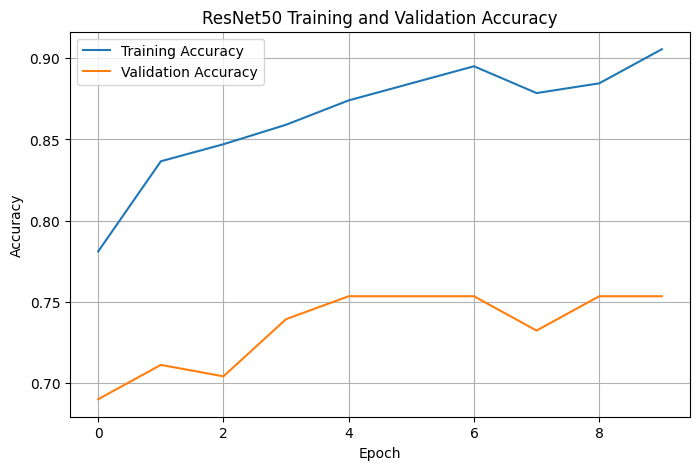

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ResNet50 Training and Validation Accuracy")
plt.legend()
plt.grid()

plt.show()

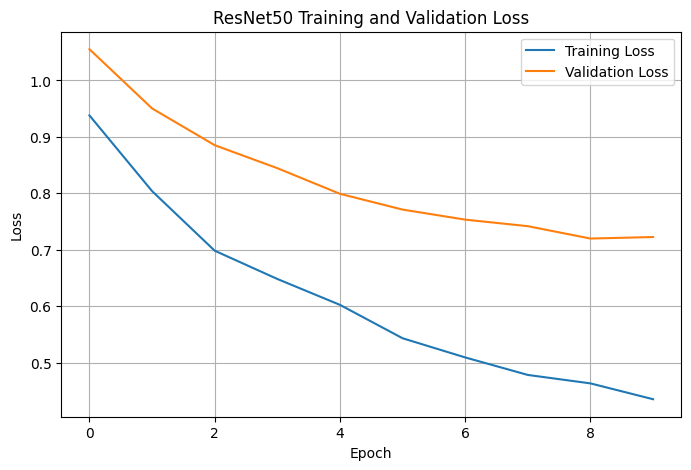

In [ ]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("ResNet50 Training and Validation Loss")
plt.legend()
plt.grid()

plt.show()

# Load the best model

In [ ]:
model.load_state_dict(
    torch.load(
        "best_resnet50_indian_paintings.pth",
        map_location=device
    )
)

model = model.to(device)

# Test the model

In [ ]:
model.eval()

all_predictions = []
all_labels = []

with torch.no_grad():

    for images, labels in test_loader:

        images = images.to(device)

        outputs = model(images)

        _, predictions = torch.max(outputs, 1)

        all_predictions.extend(
            predictions.cpu().numpy()
        )

        all_labels.extend(
            labels.numpy()
        )

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


Accuracy

In [ ]:
test_accuracy = accuracy_score(
    all_labels,
    all_predictions
)

print(
    f"Test Accuracy: {test_accuracy * 100:.2f}%"
)

Test Accuracy: 86.81%


Classification report

In [ ]:
print(
    classification_report(
        all_labels,
        all_predictions,
        target_names=base_dataset.classes
    )
)

                     precision    recall  f1-score   support

      gond painting       1.00      0.88      0.93        16
  kalighat painting       0.93      0.95      0.94        44
    kangra painting       0.85      0.79      0.81        14
       kerala mural       1.00      0.82      0.90        11
 madhubani painting       0.64      0.78      0.70         9
mandana art drawing       0.69      0.75      0.72        12
   pichwai painting       0.91      0.83      0.87        24
     warli painting       0.76      0.93      0.84        14

           accuracy                           0.87       144
          macro avg       0.85      0.84      0.84       144
       weighted avg       0.88      0.87      0.87       144



Confusion matrix

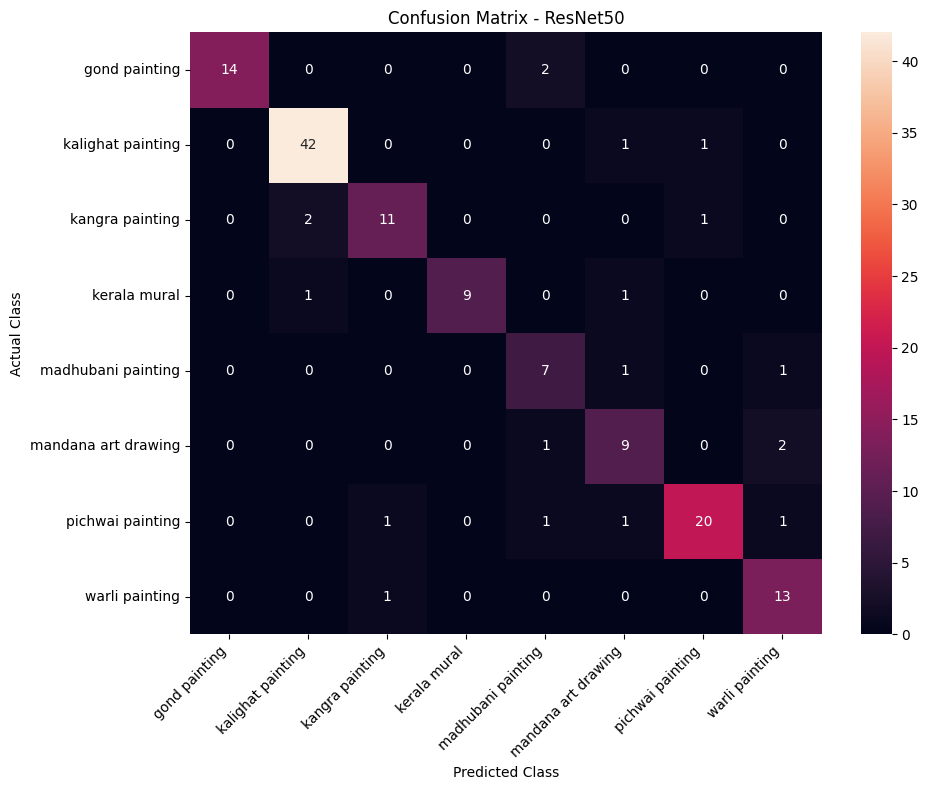

In [ ]:
cm = confusion_matrix(
    all_labels,
    all_predictions
)

plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=base_dataset.classes,
    yticklabels=base_dataset.classes
)

plt.xlabel("Predicted Class")
plt.ylabel("Actual Class")
plt.title("Confusion Matrix - ResNet50")

plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)

plt.tight_layout()
plt.show()

In [ ]:
# Save resnet50 checkpoint
from google.colab import drive
drive.mount('/content/drive')